# Session 6 — linear algebra: the numbers under every model

Data Science & AI. Module 1 Part 2 begins.

Part 1 gave you the tools — Python, NumPy, pandas. Part 2 is about what the
tools are *doing*. Tonight: **linear algebra**, which sounds like a maths
course and is actually the observation that *your data is already a matrix*
— you have been doing linear algebra since the first `DataFrame`.

Two promises for tonight, straight from the deck: every idea gets a
**picture**, and every idea gets **code**. If either one makes sense to
you, you have it.

## Before you type anything

**Work on your own copy, not on this file** — copy it into your working
folder (or **File → Save a copy in Drive** on Colab), then
**Restart & Run All**.

Tonight also wants a pen. When the deck says "do the maths by hand once
before doing it in NumPy", that is the actual advice: each new operation,
work the 2×2 example on paper first. It takes thirty seconds and it is the
difference between recognising the operation and trusting it.

In [1]:
# ==========================================================
# Setup. Run this once, then carry on.
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
print("NumPy:", np.__version__)

NumPy: 2.4.6


In [7]:
# Two little drawing helpers, used for every picture tonight. Run this
# cell and move on -- you do not need to decode it. The maths is in the
# other cells; this is just plumbing for matplotlib.
#
#   arrow(v, colour, label)  draws the vector v from the origin
#   frame(lo, hi)            square grid with both axes from lo to hi

def arrow(v, colour, label=""):
    plt.arrow(0, 0, v[0], v[1], color=colour, width=0.03,
              length_includes_head=True)
    plt.text(v[0] + 0.15, v[1] + 0.15, label, color=colour, fontsize=12)

def frame(lo, hi):
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.grid(alpha=0.3)
    plt.gca().set_aspect("equal")

## 1. Four words for four shapes of data  *(slides 3, 5)*

The deck's map, and it is worth memorising because every ML library speaks
it:

| Concept | What it is | In your data | In NumPy |
|---|---|---|---|
| **Scalar** | one number | one measurement — a customer's age | `np.float64` |
| **Vector** | a list of numbers | one row — all features of one customer | 1-D array |
| **Matrix** | a grid of numbers | the whole table — all customers | 2-D array |
| **Tensor** | a stack of grids | e.g. images: height × width × colour | n-D array |

Same objects you built in the NumPy session; tonight they get their maths
names and their maths behaviour. Why bother? Because although the world is
non-linear, **linear models are the workhorse first approximation**
*(slide 3)* — and the machinery of every model you will meet in Modules 4
to 8, including neural networks, is the two operations in this notebook:
the **dot product** and **matrix multiplication**.

## 2. Vectors  *(slides 6, 7)*

A vector is **a directed quantity** — an arrow. It has a length and a
direction. The deck's physics examples (velocity, force) all answer two
questions at once: *how much, and which way?*

For us the arrow is also a **row of data**: a patient measured as
`[resting_hr, age]` is a point in a 2-D space — an arrow from the origin
to that point. Two components, one object. Draw two of them:

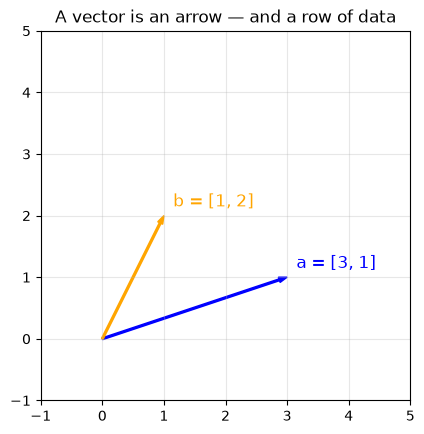

[3 1]


In [9]:
a = np.array([3, 1])
b = np.array([1, 2])

arrow(a, "blue", "a = [3, 1]")
arrow(b, "orange", "b = [1, 2]")
frame(-1, 5)
plt.title("A vector is an arrow — and a row of data")
plt.show()
print(a)

### A vector is made of shadows  *(slide 7)*

The physical reading first, because it is where vectors come from. You
walk 5 km on a bearing 37° north of east. How far east did you actually
get? How far north? Drop the arrow's **shadows** onto the two axes:

- eastward shadow: vₓ = v cos θ = 5 × 0.8 ≈ **4 km east**
- northward shadow: v_y = v sin θ = 5 × 0.6 ≈ **3 km north**

That is the deck's **vector decomposition**: one journey = the sum of a
purely-east journey and a purely-north journey. The components `[4, 3]`
*are* the vector — same information as "5 km at 37°", different
bookkeeping.

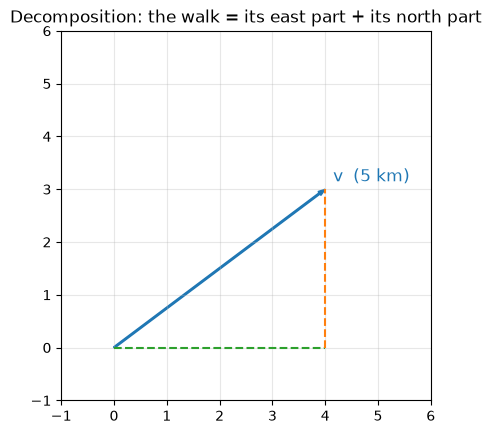

In [10]:
w = np.array([4, 3])                       # the 5 km walk

arrow(w, "tab:blue", "v  (5 km)")
plt.plot([0, 4], [0, 0], "--", color="tab:green")    # east shadow: 4 km
plt.plot([4, 4], [0, 3], "--", color="tab:orange")   # north shadow: 3 km
frame(-1, 6)
plt.title("Decomposition: the walk = its east part + its north part")
plt.show()

### Length of a vector  *(slide 7)*

Going the other way — components back to length — is Pythagoras on that
same right triangle: the **magnitude** |a| = (aₓ² + a_y²)^½, so our walk
is √(4² + 3²) = 5 km again, as it must be. The same formula works in 3
dimensions *(slide 9)*, and in 50,000: nothing changes but the number of
squares in the sum. NumPy calls it the **norm**:

In [11]:
print("the walk, by hand :", np.sqrt(4**2 + 3**2))
print("np.linalg.norm(w) :", np.linalg.norm(w))
print("np.linalg.norm(a) :", np.linalg.norm(a))

the walk, by hand : 5.0
np.linalg.norm(w) : 5.0
np.linalg.norm(a) : 3.1622776601683795


## 3. Vector arithmetic  *(slides 8, 10, 11)*

Addition is **tip-to-tail**: walk along `a`, then along `b` from where you
stopped. Component-wise, that is just adding the x's and adding the y's —
which is exactly what NumPy's `+` has done all along *(slide 8)*.

Physically this is how the world composes influences. Row a boat across a
flowing river: your velocity through the water is one arrow, the
current is another, and the bank-watcher sees you travel along their
**sum** — the resultant. Two forces on one object combine the same way,
which is why engineers draw force diagrams as arrow chains:

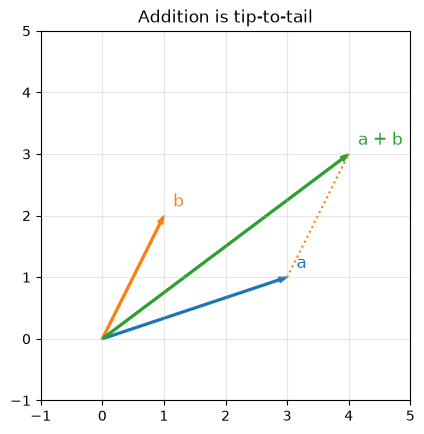

a + b = [4 3]


In [12]:
arrow(a, "tab:blue", "a")
arrow(b, "tab:orange", "b")
arrow(a + b, "tab:green", "a + b")
plt.plot([3, 4], [1, 3], ":", color="tab:orange")   # b again, from a's tip
frame(-1, 5)
plt.title("Addition is tip-to-tail")
plt.show()

print("a + b =", a + b)

Multiplying by a **scalar** stretches or shrinks the arrow without turning
it *(slide 10)*: `1.5 * a` is the same direction, one and a half times the
length. A negative scalar flips it.

And this is why NumPy vectorisation from session 3 worked the way it did —
the deck's own example *(slide 11)*: converting five temperatures at once
is *one* scalar multiplication and *one* scalar addition applied to a
whole vector.

In [13]:
temps_in_F = np.array([32, 50, 77, 104, 212])
temps_in_C = (temps_in_F - 32) * (5 / 9)
print(temps_in_C)

[  0.  10.  25.  40. 100.]


## 4. The dot product — the most important operation tonight  *(slide 12)*

Multiply the vectors component by component, **then add it all up**. The
answer is a single number — a scalar:

a · b = a₁b₁ + a₂b₂ + … + aₙbₙ

Three ways to write it in NumPy, all identical — you will meet all three
in the wild:

In [14]:
print(a)
print(b)
print("np.dot(a, b):", np.dot(a, b))
print("a @ b       :", a @ b)          # the modern operator
print("by hand     :", 3 * 1 + 1 * 2)

[3 1]
[1 2]
np.dot(a, b): 5
a @ b       : 5
by hand     : 5


So what *is* that number? The deck's geometric answer:
a · b = |a| |b| cos(θ). It measures **how aligned two vectors are**,
scaled by their lengths. Same direction → large positive. At right angles
→ cos 90° = 0. Opposite directions → negative.

> **Predict first.** Slide 12's own questions, to the chat: (1) two vectors have dot product exactly zero — what does that say about them? (2) what is a · a, the dot product of a vector with itself?
>
> Put your answer in the chat before we run it.

In [15]:
right_angle = np.array([-1, 3])          # perpendicular to a = [3, 1]
print("a · perpendicular :", a @ right_angle)
print("a · a             :", a @ a)
print("|a| squared       :", np.linalg.norm(a) ** 2)

a · perpendicular : 0
a · a             : 10
|a| squared       : 10.000000000000002


Zero means **perpendicular** — no alignment at all, nothing in common. And
a · a is the vector's **length squared**: Pythagoras again, wearing a
different hat.

### What the dot product is, physically: a shadow, and work

The picture that makes |a||b| cos θ stop being a formula: drop a's
**shadow onto b's direction** (decomposition again — but onto b's line
instead of the x-axis). The shadow's length is |a| cos θ, and the dot
product is *shadow length × |b|*: **only the part of a that points
along b counts.**

Physics runs on exactly this. Drag a sled with a rope that slopes upward:
force F = [6, 2] newtons, but the sled moves horizontally, d = [4, 0]
metres. The **work** done — energy actually delivered — is W = F · d.
The upward 2 N tilts the rope; it moves the sled nowhere, and the dot
product silently discards it:

In [ ]:
F = np.array([6, 2])          # newtons: 6 along the ground, 2 upward
d = np.array([4, 0])          # metres: the sled moves along the ground

print("work F · d           :", F @ d, "joules")
print("horizontal part alone:", 6 * 4, "joules  -- the vertical 2 N did nothing")

arrow(F, "tab:red", "F (rope force)")
arrow(d, "tab:blue", "d (motion)")
plt.plot([6, 6], [0, 2], "--", color="grey")   # drop F's shadow onto d
frame(-1, 7)
plt.title("Work = shadow of the force x the distance = F . d")
plt.show()

Same operation, three costumes: *sum of products* (the computation),
*alignment* (the geometry), *work* (the physics). They are provably the
same number.

Why a data scientist cares: "how aligned are these two things" is a
similarity measure. Two customers as feature vectors, two documents as
word counts — their dot product (normalised: **cosine similarity**) is how
recommender systems and search engines decide that two things are alike.
And inside every neural network, each neuron computes *exactly one dot
product* of its inputs with its weights. That is the whole trick.

One trap before we move on: `*` is **not** the dot product. `a * b`
multiplies component-wise and *stops* — no summing — returning a vector,
not a number. The deck calls it the Hadamard product *(slide 13)*. Both
are useful; do not confuse them.

In [17]:
print(a)
print(b)
print("a * b (Hadamard, element-wise):", a * b)
print("a @ b (dot, with the sum)     :", a @ b)

[3 1]
[1 2]
a * b (Hadamard, element-wise): [3 2]
a @ b (dot, with the sum)     : 5


> **Checkpoint.** Quick poll on Slidea: dot product of [2, 0] and [0, 5] — in your head, no NumPy.

## 5. Matrices  *(slides 14, 15, 16, 18)*

A matrix is **a rectangular array of numbers** *(slide 14)* — n rows by m
columns. You have one already: `DataFrame.values` from the pandas session
is exactly this, one row per observation, one column per feature.

**Addition** is element-wise, same as vectors *(slide 15)*.
**Transpose** flips it — the rows of Aᵀ are the columns of A *(slide 18)*:

In [18]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[10, 20],
              [30, 40]])

print("A + B:\n", A + B)
print()
print("A transpose (rows become columns):\n", A.T)

A + B:
 [[11 22]
 [33 44]]

A transpose (rows become columns):
 [[1 3]
 [2 4]]


### Matrix multiplication  *(slide 16)*

Here is the one that is *not* element-wise, and the deck's note is the
whole rule worth keeping:

> the (i, j) entry of AB is **the dot product of row i of A with column j
> of B**.

So matrix multiplication is not a new operation — it is the section-4 dot
product, done for every row-column pair. On paper, once, for the top-left
entry: row [1, 2] · column [10, 30] = 10 + 60 = **70**.

In [19]:
print(A)
print(B)
print("A @ B:\n", A @ B)
print()
print("top-left, by hand:", 1 * 10 + 2 * 30)

[[1 2]
 [3 4]]
[[10 20]
 [30 40]]
A @ B:
 [[ 70 100]
 [150 220]]

top-left, by hand: 70


Shapes must agree: **(m × n) @ (n × p) → (m × p)** — the inner numbers
must match, and they are consumed *(slide 16)*. That single rule explains
most of the errors you will ever see from ML libraries.

### Deliberate error

Read the message from the bottom up, and diagnose it with the shape rule
before we discuss.

In [20]:
C = np.array([[1, 2, 3],
              [4, 5, 6]])       # shape (2, 3)
C @ A                            # A is (2, 2) -- inner numbers: 3 vs 2

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

`matmul: ... size 3 is different from 2` — the inner dimensions disagree:
(2, **3**) @ (**2**, 2) has 3 against 2. Every "shapes not aligned" error
from sklearn, TensorFlow or PyTorch is this line wearing a costume. The
fix is never to shuffle things until it runs — it is to ask *which shape
is wrong and why*. (Here, `C @ A` is unaskable, but `A @ C` — (2,2)@(2,3)
— is fine.)

## 6. What multiplication *means*: transformation  *(slide 17)*

The second answer to "what is a matrix": a matrix is a **machine that
moves vectors**. Multiply a vector by a matrix and you get a new vector —
the input, transformed. The deck's example: this matrix flips things
across the y-axis.

v       : [3 1]
FLIP @ v: [-6  2]


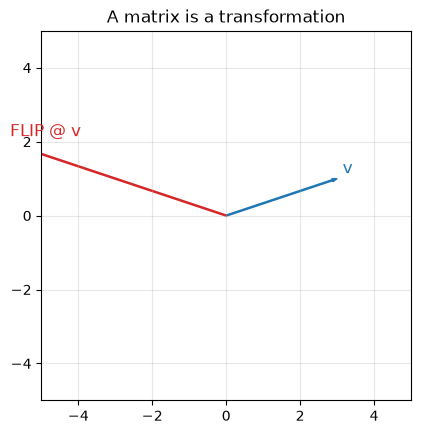

In [22]:
FLIP = np.array([[-1, 0],
                 [ 0, 1]])

v = np.array([3, 1])
print("v       :", v)
print("FLIP @ v:", FLIP @ v)

arrow(v, "tab:blue", "v")
arrow(FLIP @ v, "tab:red", "FLIP @ v")
frame(-5, 5)
plt.title("A matrix is a transformation")
plt.show()

Rotations, stretches, projections — each is a small matrix. Chain them by
multiplying the matrices. When Module 8 rotates and scales images for a
neural network, this is the machinery.

Both views are true at once, and it is worth saying plainly:
**a matrix is a table of data, and a matrix is a transformation.** Which
one it *is* depends on how you are using it — the deck's mapping table
said exactly this back on slide 5.

## 7. Three special facts about square matrices  *(slides 19, 20, 21)*

**The determinant** *(slide 19)* is one number that says how much a
transformation scales area. For a 2×2 it is `ad - bc` 


**The identity matrix** *(slide 20)* is the do-nothing transformation:
ones on the diagonal. `A @ I = I @ A = A` — the matrix world's number 1.

**The inverse** *(slide 21)* is the undo button: A⁻¹ is the matrix such
that `A⁻¹ @ A = I`. Apply A, apply A⁻¹, you are back where you started.
It exists only if A is square **and det(A) ≠ 0** — you cannot undo a
flattening.

In [23]:

print("det(A)   :", np.linalg.det(A))

I = np.eye(2)
print("\nA @ I equals A:\n", A @ I)

A_inv = np.linalg.inv(A)
print("A_inv @ A (should be I):\n", A_inv @ A)

det(A)   : -2.0000000000000004

A @ I equals A:
 [[1. 2.]
 [3. 4.]]
A_inv @ A (should be I):
 [[1. 0.]
 [0. 1.]]


In [26]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

### Deliberate error

A matrix whose second row is twice its first — the rows carry the same
information, det = 0, space gets flattened. Ask for the impossible:

In [ ]:
S = np.array([[1, 2],
              [2, 4]])          # row 2 = 2 x row 1, det = 0
np.linalg.inv(S)

`LinAlgError: Singular matrix` — **singular** is the maths word for
det = 0, no inverse, cannot be undone. You will meet this exact error in
Module 4 when a regression has a redundant column (one feature is a copy
or combination of others). Now you know what it is actually saying: two
rows, one piece of information.

> **Checkpoint.** Pace check on Slidea before the payoff section.

## 8. The payoff: solving many equations at once  *(slides 22, 23)*

The problem linear algebra was built for. A pharmacy stocks two supplement
blends. Blend one has 2 g of iron and 1 g of zinc per dose; blend two has
1 g of iron and 3 g of zinc. A patient needs exactly 8 g of iron and 9 g
of zinc. How many doses of each?

As simultaneous equations:

```
2x + 1y = 8      (iron)
1x + 3y = 9      (zinc)
```

The deck's move *(slide 22)*: stack the coefficients into a matrix and
both unknowns into a vector, and the whole system collapses to one line —
**A x = b**. Then the solution is one application of the undo button
*(slide 23)*: **x = A⁻¹ b**.

> **Predict first.** Two equations, two unknowns — solvable by school algebra in a minute. Roughly how many *more* lines of code will fifty thousand equations with fifty thousand unknowns need?
>
> Put your answer in the chat before we run it.

In [28]:
A_sys = np.array([[2, 1],
                  [1, 3]])
b_sys = np.array([8, 9])

X = np.linalg.solve(A_sys, b_sys)
print("doses:", x)
print("check A @ x:", A_sys @ X)

doses: [3. 2.]
check A @ x: [8. 9.]


Three doses of blend one, two of blend two — and the check multiplies
back to exactly [8, 9].

The answer to the prediction: **zero**. `np.linalg.solve` does not care
whether A is 2×2 or 50,000×50,000; the notation Ax = b and the code are
identical. That scale-blindness is *the* reason this notation runs the
field.

One professional habit while we are here: `solve(A, b)` rather than
`inv(A) @ b`. Same mathematics, but `solve` is faster and numerically
safer — the inverse is a concept to think with, not usually a thing to
compute.

And a preview you will meet again in week 8: linear regression on a
50,000-row dataset is *literally this* — the best-fit coefficients solve
one matrix equation built from the data. Same `solve`, bigger A.

## 9. Sixty seconds each: eigenvectors and tensors  *(slides 24, 25)*

**Eigenvectors** *(slide 24)*. Most vectors, pushed through a matrix, get
turned. A few special ones do not — the matrix only *stretches* them:
T(v) = λv. Those directions are the matrix's **eigenvectors**, and each
stretch factor λ is an **eigenvalue** — the transformation's natural
axes. Push three directions through M = [[3, 1], [1, 3]] and watch two
of them refuse to turn:

[1 0] -> [3 1]
[1 1] -> [4 4]
[-1  1] -> [-2  2]


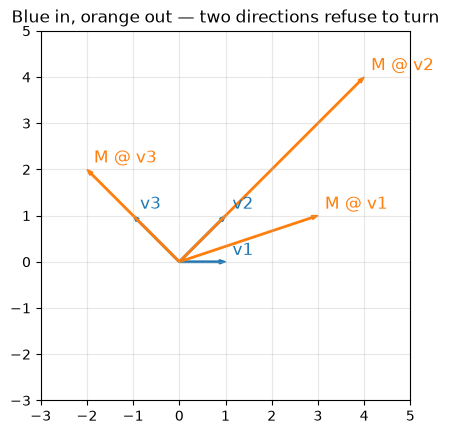

In [30]:
M = np.array([[3, 1],
              [1, 3]])

v1 = np.array([1, 0])       # an ordinary direction
v2 = np.array([1, 1])       # special
v3 = np.array([-1, 1])      # special

# for v in (v1, v2, v3):
#     print(v)
# arrow(v1, "tab:blue", "v1")
# arrow(v2, "tab:blue", "v2")
# arrow(v3, "tab:blue", "v3")
for v in (v1, v2, v3):
    print(v, "->", M @ v)

arrow(v1, "tab:blue", "v1");  arrow(M @ v1, "tab:orange", "M @ v1")
arrow(v2, "tab:blue", "v2");  arrow(M @ v2, "tab:orange", "M @ v2")
arrow(v3, "tab:blue", "v3");  arrow(M @ v3, "tab:orange", "M @ v3")
frame(-3, 5)
plt.title("Blue in, orange out — two directions refuse to turn")
plt.show()

`v1 = [1, 0]` came out at `[3, 1]` — turned, like most vectors. But
`v2 = [1, 1]` came out at `[4, 4]` — same direction, four times longer.
And `v3 = [-1, 1]` came out at `[-2, 2]` — same direction, twice as
long. Those two unturned directions are the eigenvectors, with
eigenvalues λ = 4 and λ = 2, and `np.linalg.eig` finds them without
drawing:

In [31]:
values, vectors = np.linalg.eig(M)
print("eigenvalues :", values)
print("first eigenvector:", vectors[:, 0], "-> M stretches it by", values[0])
print("check:  M @ v =", M @ vectors[:, 0], " = 4 * v =", 4 * vectors[:, 0])

eigenvalues : [4. 2.]
first eigenvector: [0.707 0.707] -> M stretches it by 4.0
check:  M @ v = [2.828 2.828]  = 4 * v = [2.828 2.828]


The physical world is full of these unturned axes. A spinning globe
turns every point except the two on its **axis of rotation** — in 3-D, a
rotation's axis is its eigenvector, stretch factor 1. Squeeze a block of
material and the deck's slide-25 **stress tensor** has three
eigenvectors: the principal directions along which the material is
purely compressed or stretched, no shearing — the axes an engineer
checks before a bridge is signed off. (And a caution that keeps the
concept honest: a flat 2-D rotation has *no* real eigenvectors — every
direction turns. Not every matrix has these special axes in real
numbers.)

Where a data scientist meets them: **PCA** in Module 4 finds the
eigenvectors of a dataset's spread — the directions along which the data
naturally varies — and uses them to compress fifty columns into the two
or three that matter.

**Tensors** *(slide 25)*: the ladder does not stop at 2-D. A colour image
is height × width × 3, a batch of a thousand images is a 4-D block. NumPy
just adds axes; count them with `ndim` — and that is the entire reason
the library is called TensorFlow.

In [3]:
scalar = np.array(37.5)
vector = np.array([37.5, 36.8])
matrix = np.array([[37.5, 36.8], [38.1, 37.0]])
tensor = np.zeros((10, 2, 2))          # ten such matrices, stacked

for thing in (scalar, vector, matrix, tensor):
    print(thing.ndim, "dimensions - shape", thing.shape)

0 dimensions - shape ()
1 dimensions - shape (2,)
2 dimensions - shape (2, 2)
3 dimensions - shape (10, 2, 2)


In [ ]:
tensor


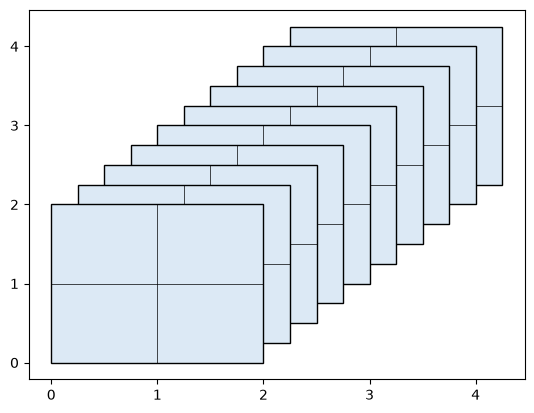

In [6]:
for k in range(10):                    # sheet 0 in front, sheet 9 at the back
    o = 0.25 * k                       # push each sheet back a little
    z = 10 - k                         # so front sheets draw on top
    plt.fill([o, o + 2, o + 2, o], [o, o, o + 2, o + 2],
             color="#dce9f5", edgecolor="black", zorder=z)
    plt.plot([o + 1, o + 1], [o, o + 2], color="black", lw=0.5, zorder=z)
    plt.plot([o, o + 2], [o + 1, o + 1], color="black", lw=0.5, zorder=z)

---

## Your turn

The deck's Lab 1.2.1 (Vector and Matrix Operations) is tonight's official
lab. These warm you up for it — each is a few lines.

In [ ]:
# 1. u = [2, 5, 1] and w = [4, 0, 3]. Compute u + w, 3 * u, and u . w
#    (the dot product). Do the dot product on paper first, then check.

In [ ]:
# 2. Are [2, -3] and [3, 2] perpendicular? Answer with one dot product,
#    and say how you know.

In [ ]:
# 3. P = [[1, 2], [3, 5]].  Compute det(P), then P_inv, then verify
#    P_inv @ P gives the identity (allow for tiny floating-point dust).

In [ ]:
# 4. Coffee: 2 flat whites and 1 muffin cost $13; 1 flat white and
#    3 muffins cost $14. Set up A and b, and solve for the two prices.
#    Save the answer as `prices`. Ax = b

In [36]:
# 2 f + 1 m = 13
# 1 f + 3 m = 14
A = np.array([[2,1],
             [1,3]])
b = np.array([13,14])
prices =  np.linalg.solve(A,b)
print(prices)

[5. 3.]


$$
\begin{pmatrix} 
2 & 1 \\ 
1 & 3 
\end{pmatrix} 
\begin{pmatrix} 
f \\ 
y 
\end{pmatrix} 
= 
\begin{pmatrix} 
(2 \cdot f) + (1 \cdot y) \\ 
(1 \cdot f) + (3 \cdot y) 
\end{pmatrix} 
= 
\begin{pmatrix} 
2f + y \\ 
f + 3y 
\end{pmatrix}
$$

### Check your own work

In [ ]:
if "prices" not in dir():
    print("Finish task 4 first, then run this cell again.")
else:
    assert np.allclose(prices, [5, 3]), \
        "expected a $5 flat white and a $3 muffin, got {}".format(prices)
    print("all checks pass: flat white $5, muffin $3")

### Stretch

1. Write `angle_between(u, w)` returning the angle in degrees, using
   a·b = |a||b|cos θ. Test it on two perpendicular vectors.
2. Rotation matrix: R = [[cos θ, -sin θ], [sin θ, cos θ]] for θ = 90°.
   Apply it to [1, 0] and draw before/after with the `arrow` helper.
3. `np.linalg.eig` on the FLIP matrix from section 6. One eigenvalue is
   -1: which direction does it belong to, and why does that make sense
   for a mirror?

### If you want the pictures again, slower

Three sources whose geometric style tonight borrowed, all free:

- **Dr Trefor Bazett** — [youtube.com/@DrTrefor](https://www.youtube.com/@DrTrefor):
  his linear algebra playlist walks every one of tonight's ideas with
  animated visuals, at lecture pace with the proofs available when you
  want them.
- **3Blue1Brown, *Essence of Linear Algebra*** —
  [3blue1brown.com/topics/linear-algebra](https://www.3blue1brown.com/topics/linear-algebra):
  the famous animated series; chapters 3 (transformations), 5
  (determinant) and 14 (eigenvectors) are tonight's sections 6, 7 and 9.
- **Khan Academy** —
  [khanacademy.org/math/linear-algebra](https://www.khanacademy.org/math/linear-algebra):
  worked exercises with instant feedback, good for drilling the
  mechanics before the lab.

---

*Data Science & AI — Session 6. Covers Module 1 Part 2 slides 3–26.
Official lab: IOD Lab 1.2.1 Vector Matrix Operations (`labs/lab1/`).*